# PUC-Rio
## Departamento de Engenharia Elétrica
## Lista de Exercícios — Séries Temporais com MLP

---

**Estudante:**

**Base de dados escolhida:**

---

> **Instruções gerais:**
> - Execute **todas** as células de configuração antes de responder.
> - Responda nas células Markdown indicadas com ` Resposta:`.
> - A maioria das questões já possuem uma implementação de código. Quando for necessário escrever um código, faça-as nas células marcadas com `# SEU CÓDIGO AQUI`.
> - Use métricas quantitativas (MSE, RMSE, MAE) sempre que pertinente.
> - Esta lista explora **duas abordagens**: (1) MLP com múltiplas variáveis de entrada e saída univariada (**MISO**); (2) MLP com saída multivariada (**MIMO**), para explorar a abordagem multivariada.

---
## Configuração do Ambiente

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

In [18]:
class TimeSeriesDataset(Dataset):
    """Dataset PyTorch genérico para séries temporais janeladas.
    Aceita y com shape (N,) para saída univariada ou (N, H) para saída multivariada.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32)
        self.y = y_t.unsqueeze(1) if y_t.dim() == 1 else y_t  # (N,1) ou (N,H)

    def __getitem__(self, i): return self.X[i], self.y[i]
    def __len__(self):        return len(self.X)

In [19]:
class MLP(nn.Module):
    """
    Rede Neural MLP configurável.
    Versão relativamente diferente ao apresentado em sala de aula. Neste, é feito uso
    artefato de um modelo "sequential", simplificando a implementação.
    Parâmetros
    ----------
    n_input      : int  — dimensão da entrada
    hidden_layers: list — neurônios por camada oculta, ex: [64, 32]
    n_output     : int  — dimensão da saída (1 para MISO; n_vars para MIMO)
    activation   : str  — 'relu', 'sigmoid' ou 'tanh'
    """
    _acts = {'relu': nn.ReLU, 'sigmoid': nn.Sigmoid, 'tanh': nn.Tanh}

    def __init__(self, n_input=10, hidden_layers=[64], n_output=1, activation='relu'):
        super().__init__()
        act_cls = self._acts[activation]
        layers, in_dim = [], n_input
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), act_cls()]
            in_dim = h
        layers.append(nn.Linear(in_dim, n_output))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)

In [20]:
def make_windows_univariate(series, window_size, horizon=1):
    """
    Janela deslizante para série 1-D (abordagem univariada).

    Retorna
    -------
    X : (N, window_size)
    y : (N,) se horizon==1  |  (N, horizon) se horizon>1
    """
    X, y = [], []
    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i : i + window_size])
        chunk = series[i + window_size : i + window_size + horizon]
        y.append(chunk[0] if horizon == 1 else chunk)
    return np.array(X), np.array(y)


def make_windows_multivariate(df_scaled, target_col, feature_cols,
                               window_size, horizon=1, mode='MISO'):
    """
    Janela deslizante para dados multivariados.

    Parâmetros
    ----------
    df_scaled   : pd.DataFrame normalizado
    target_col  : str   — coluna alvo
    feature_cols: list  — colunas usadas como features (inclui target_col)
    window_size : int
    horizon     : int
    mode        : 'MISO' — saída = próximo(s) valor(es) do target_col
                  'MIMO' — saída = próximos valores de TODAS as feature_cols

    Retorna
    -------
    X : (N, window_size * n_features)
    y : (N,) ou (N, horizon)          para MISO
        (N, n_features)               para MIMO com horizon==1
        (N, horizon * n_features)     para MIMO com horizon>1
    """
    data   = df_scaled[feature_cols].values     # (T, F)
    target = df_scaled[target_col].values       # (T,)
    n_feat = len(feature_cols)
    X, y   = [], []

    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size].ravel())          # flatten → (W*F,)
        if mode == 'MISO':
            chunk = target[i + window_size : i + window_size + horizon]
            y.append(chunk[0] if horizon == 1 else chunk)
        else:  # MIMO
            chunk = data[i + window_size : i + window_size + horizon]  # (H, F)
            y.append(chunk.ravel())                          # (H*F,)

    return np.array(X), np.array(y)

In [21]:
def train_model(model, loader, epochs=500, lr=1e-3, loss_fn=None, verbose=True):
    """Treina um modelo MLP e retorna o histórico de perda por época."""
    if loss_fn is None:
        loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = []
    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history.append(epoch_loss / len(loader))
        if verbose and epoch % 100 == 0:
            print(f"Época {epoch:4d}/{epochs} | Perda: {history[-1]:.6f}")
    return history

In [22]:
def recursive_forecast_univariate(model, X_seed, horizon):
    """
    Previsão recursiva para modelo one-step univariado.
    X_seed : np.ndarray (window_size,)
    """
    model.eval()
    window, preds = X_seed.copy(), []
    with torch.no_grad():
        for _ in range(horizon):
            x_t = torch.tensor(window, dtype=torch.float32).unsqueeze(0)
            y_hat = model(x_t).item()
            preds.append(y_hat)
            window = np.roll(window, -1)
            window[-1] = y_hat
    return np.array(preds)


def recursive_forecast_multivariate(model, X_seed, horizon, window_size, n_features):
    """
    Previsão recursiva para modelo MISO multivariado.
    X_seed : np.ndarray (window_size * n_features,)  — janela inicial achatada
    Retorna apenas as previsões do target (primeira feature por convenção).
    """
    model.eval()
    window = X_seed.reshape(window_size, n_features).copy()  # (W, F)
    preds  = []
    with torch.no_grad():
        for _ in range(horizon):
            x_t   = torch.tensor(window.ravel(), dtype=torch.float32).unsqueeze(0)
            y_hat = model(x_t).item()          # previsão do target
            preds.append(y_hat)
            # Desliza a janela: descarta t mais antigo, acrescenta t+1
            new_row        = window[-1].copy()  # repete as exógenas do último passo
            new_row[0]     = y_hat              # atualiza o target (posição 0 por convenção)
            window         = np.vstack([window[1:], new_row])
    return np.array(preds)

In [23]:
def rrse_naive(y_true, y_pred):
    """
    RRSE com baseline naive: y_{t+1} ≈ y_t

    Parâmetros:
    - y_true: array com valores reais (y_{t+1})
    - y_pred: array com previsões do modelo (ŷ_{t+1})

    Retorna:
    - rrse (float)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # garante alinhamento temporal
    if len(y_true) != len(y_pred):
        raise ValueError("y_true e y_pred devem ter o mesmo tamanho")

    num = np.sum((y_true - y_pred) ** 2)

    # denominador: erro do naive (y_t)
    # precisamos de y_t → shift de y_true
    y_t = y_true[:-1]
    y_t1 = y_true[1:]

    denom = np.sum((y_t1 - y_t) ** 2)

    if denom == 0:
        return np.nan  # ou np.inf dependendo do caso

    return np.sqrt(num / denom)

def evaluate(y_true, y_pred, label='Modelo', scaler=None, target_idx=0):
    """
    Calcula e exibe MSE, RMSE, MAE e SSE.
    Se scaler não for None, desnormaliza antes de calcular.
    target_idx: coluna do target caso y seja multivariado.
    """
    yt, yp = np.array(y_true).ravel(), np.array(y_pred).ravel()
    if scaler is not None:
        # Desnormaliza somente a coluna do target
        def inv(v):
            tmp = np.zeros((len(v), scaler.n_features_in_))
            tmp[:, target_idx] = v
            return scaler.inverse_transform(tmp)[:, target_idx]
        yt, yp = inv(yt), inv(yp)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp)
    rrse = rrse_naive(yt, yp)
    sse  = np.sum((yt - yp) ** 2)
    print(f"[{label}]  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  SSE={sse:.2f}  MAPE={mape:.2f}  RRSE*:{rrse:.2f}")
    return mse, rmse, mae, sse

---
### Carregamento e Configuração do Dataset

Esta lista, a princípio, funciona para **qualquer série multivariada**.  
O exemplo padrão usa o dataset **Air Quality** (UCI), mas você pode substituir pela URL ou caminho de outro dataset.

Caso use outro dataset, não esqueça de configurar os seguintes itens abaixo.

**Parâmetros que você deve configurar:**

| Parâmetro | Descrição |
|---|---|
| `TARGET_COL` | Coluna a ser prevista |
| `FEATURE_COLS` | Lista de variáveis usadas como entrada (inclui `TARGET_COL`) |
| `WINDOW_SIZE` | Tamanho da janela temporal |
| `HORIZON` | Número de passos à frente para previsão multi-step |
| `TEST_SPLIT` | Proporção do conjunto de teste |

In [24]:
# ============================================================
#  CONFIGURAÇÃO — modifique conforme o dataset escolhido
# ============================================================

# --- Dataset: Air Quality (UCI) ---
# Variáveis: CO(GT), PT08.S1(CO), NMHC(GT), C6H6(GT),
#            PT08.S2(NMHC), NOx(GT), PT08.S3(NOx),
#            NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH

DATA_URL = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/'
    '00360/AirQualityUCI.zip'
)

# --- Ou use um dos datasets do repositório da disciplina ---
# DATASET_NAME = 'microclima1'
# DATA_URL = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/s_{DATASET_NAME}.csv'

# ============================================================
#  Parâmetros globais
# ============================================================
TARGET_COL   = 'CO(GT)'        # variável alvo
FEATURE_COLS = [               # features de entrada (inclua TARGET_COL)
    'CO(GT)', 'PT08.S1(CO)', 'T', 'RH'
]
WINDOW_SIZE  = 12
HORIZON      = 6
TEST_SPLIT   = 0.15
BATCH_SIZE   = 32
# ============================================================

In [25]:
# Essa parte é apenas para o airquality dataset. Se for qualquer outro, substitua pelo que for adequado para leitura do dataset.

import io, zipfile, urllib.request

resp = urllib.request.urlopen(DATA_URL)
z    = zipfile.ZipFile(io.BytesIO(resp.read()))
raw_data = pd.read_csv(
    z.open('AirQualityUCI.csv'),
    sep=';', decimal=',', parse_dates={'datetime': ['Date','Time']},
    dayfirst=True
)

raw_data.replace(-200, np.nan, inplace=True)
#raw_data.dropna(subset=FEATURE_COLS, inplace=True)
raw_data.fillna(method='ffill',inplace=True)
raw_data.reset_index(drop=True, inplace=True)

print(f"Shape após limpeza : {raw_data.shape}")
print(f"Colunas disponíveis: {raw_data.select_dtypes(include=np.number).columns.tolist()}")
raw_data[FEATURE_COLS].describe().round(2)

Shape após limpeza : (9471, 16)
Colunas disponíveis: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']


,CO(GT),PT08.S1(CO),T,RH
count,9471.00,9471.00,9471.00,9471.00
mean,2.08,1102.35,18.44,48.39
std,1.46,218.29,8.84,17.68
min,0.10,647.00,-1.90,9.20
25%,1.00,940.00,11.90,34.90
50%,1.70,1065.00,17.70,48.60
75%,2.70,1235.00,24.60,61.70
max,11.90,2040.00,44.60,88.70


In [26]:
n_samples = len(raw_data)
n_test    = int(n_samples * TEST_SPLIT)
n_train   = n_samples - n_test

scaler = MinMaxScaler()
scaler.fit(raw_data[FEATURE_COLS].values[:n_train])

scaled_values = scaler.transform(raw_data[FEATURE_COLS].values)
df_scaled = pd.DataFrame(scaled_values, columns=FEATURE_COLS)

target_idx = FEATURE_COLS.index(TARGET_COL)   # posição do target na lista de features
n_features = len(FEATURE_COLS)

print(f"Amostras totais : {n_samples}  |  Treino: {n_train}  |  Teste: {n_test}")
print(f"Features ({n_features}): {FEATURE_COLS}")
print(f"Target          : '{TARGET_COL}' (índice {target_idx})")

Amostras totais : 9471  |  Treino: 8051  |  Teste: 1420
Features (4): ['CO(GT)', 'PT08.S1(CO)', 'T', 'RH']
Target          : 'CO(GT)' (índice 0)


---
# Seção 1 — Pré-processamento, Análise e Transformação de Dados

---
### Q1 — Análise Exploratória da Série

Execute o código abaixo para visualizar a variável alvo. Analise e responda:

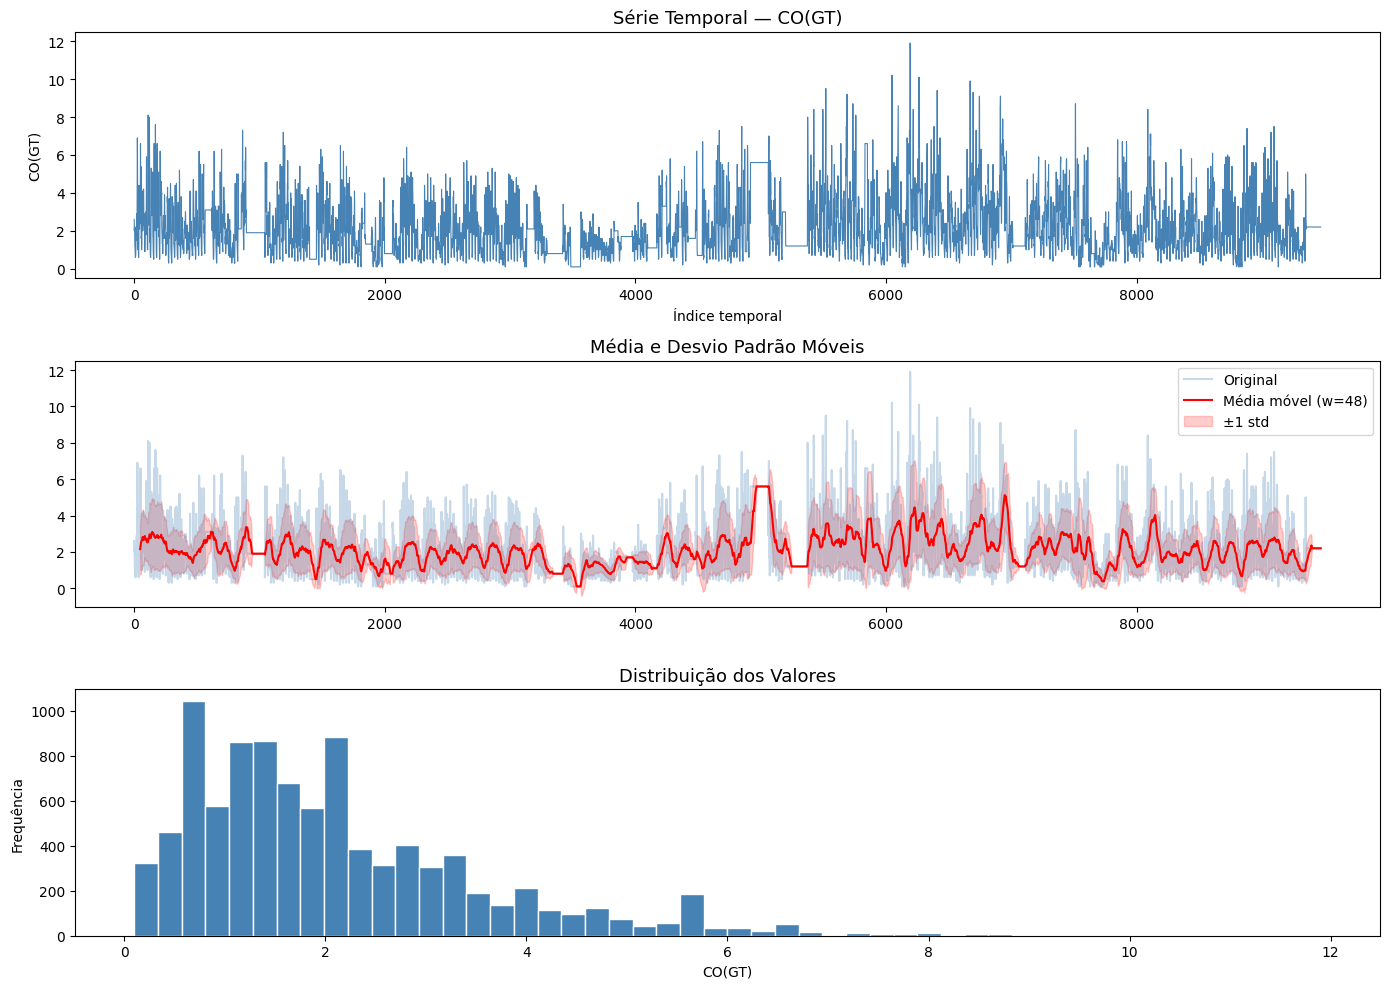

count    9471.000
mean        2.084
std         1.461
min         0.100
25%         1.000
50%         1.700
75%         2.700
max        11.900
dtype: float64


In [27]:
# --- Código fornecido ---
series_raw = raw_data[TARGET_COL].values

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(series_raw, color='steelblue', linewidth=0.8)
axes[0].set_title(f'Série Temporal — {TARGET_COL}', fontsize=13)
axes[0].set_xlabel('Índice temporal')
axes[0].set_ylabel(TARGET_COL)

win = 48
roll_mean = pd.Series(series_raw).rolling(win).mean()
roll_std  = pd.Series(series_raw).rolling(win).std()
axes[1].plot(series_raw, alpha=0.3, label='Original', color='steelblue')
axes[1].plot(roll_mean, color='red',  label=f'Média móvel (w={win})')
axes[1].fill_between(range(len(series_raw)),
                     roll_mean - roll_std, roll_mean + roll_std,
                     alpha=0.2, color='red', label='±1 std')
axes[1].set_title('Média e Desvio Padrão Móveis', fontsize=13)
axes[1].legend()

axes[2].hist(series_raw, bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Distribuição dos Valores', fontsize=13)
axes[2].set_xlabel(TARGET_COL)
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()
print(pd.Series(series_raw).describe().round(3))

**Resposta Q1:**

**a) A série apresenta tendência?**
> *Escreva aqui.*

**b) Há indícios de sazonalidade?**
> *Escreva aqui.*

**c) O comportamento parece estacionário?**
> *Escreva aqui.*

---
### Q2 — Estrutura Multivariada

O código abaixo visualiza todas as variáveis disponíveis e suas relações com o target. Com base nos resultados, defina quais variáveis incluir em `FEATURE_COLS` (você pode alterar a configuração e rodar novamente).

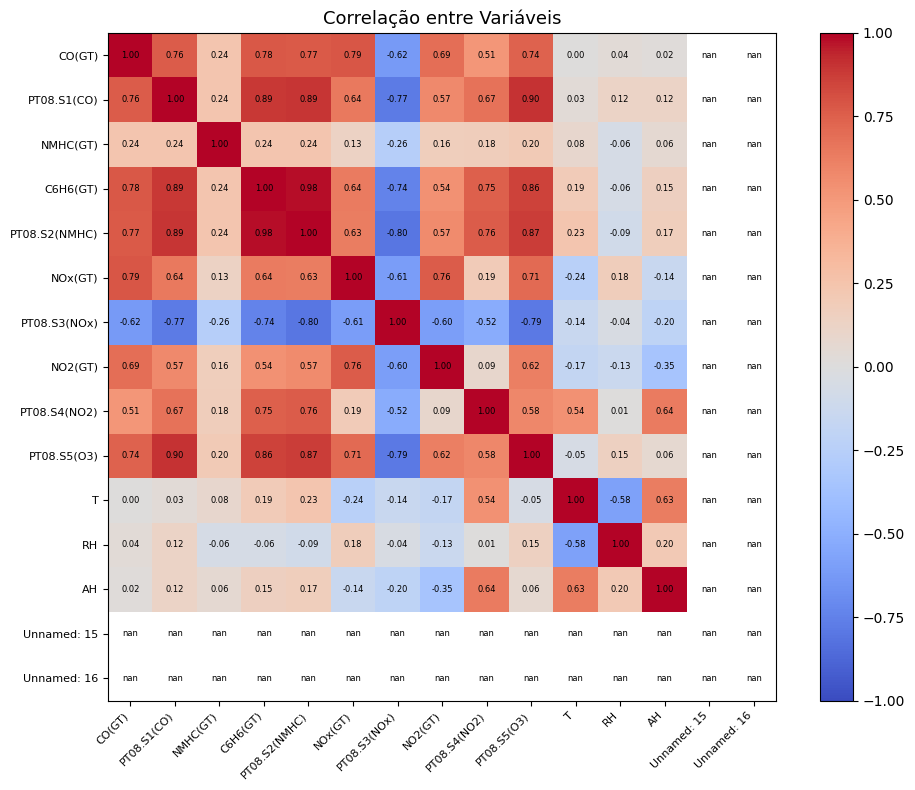


Correlação de cada variável com 'CO(GT)':
  CO(GT)                         r = +1.0000
  PT08.S1(CO)                    r = +0.7630
  NMHC(GT)                       r = +0.2385
  C6H6(GT)                       r = +0.7790
  PT08.S2(NMHC)                  r = +0.7687
  NOx(GT)                        r = +0.7879
  PT08.S3(NOx)                   r = -0.6193
  NO2(GT)                        r = +0.6885
  PT08.S4(NO2)                   r = +0.5089
  PT08.S5(O3)                    r = +0.7353
  T                              r = +0.0026
  RH                             r = +0.0390
  AH                             r = +0.0219
  Unnamed: 15                    r = +nan
  Unnamed: 16                    r = +nan

Autocorrelação de 'CO(GT)' com suas defasagens:
  lag=  1  r = +0.8685
  lag=  2  r = +0.6822
  lag=  3  r = +0.5309
  lag=  6  r = +0.2984
  lag= 12  r = +0.2404
  lag= 24  r = +0.6061


In [28]:
# --- Código fornecido: correlação e defasagens ---
num_cols = raw_data.select_dtypes(include=np.number).columns.tolist()

# Matriz de correlação
corr = raw_data[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6)
ax.set_title('Correlação entre Variáveis', fontsize=13)
plt.tight_layout(); plt.show()

# Correlação do target com variáveis e com defasagens do próprio target
print(f"\nCorrelação de cada variável com '{TARGET_COL}':")
for col in num_cols:
    r = raw_data[TARGET_COL].corr(raw_data[col])
    print(f"  {col:30s} r = {r:+.4f}")

print(f"\nAutocorrelação de '{TARGET_COL}' com suas defasagens:")
s = raw_data[TARGET_COL]
for lag in [1, 2, 3, 6, 12, 24]:
    print(f"  lag={lag:3d}  r = {s.corr(s.shift(lag)):+.4f}")

**Resposta Q2:**

**a) Quais variáveis têm maior correlação com o target? Elas são adequadas como features?**
> *Escreva aqui.*

**b) Existe correlação com defasagens do próprio target? O que isso indica?**
> *Escreva aqui.*

**c) Justifique as variáveis que você incluiu em `FEATURE_COLS`.**

Dica: observe que existem valores com PT08 e GT, como PT08.S1(CO) e CO(GT). Os valores com PT indicam aqueles medidos pelos sensores, e aqueles com GT sinalizam os valores Ground Truth (i.e., a quantidade de CO no ar).
> *Escreva aqui.*

---
### Q3 — Construção da Janela Temporal Multivariada

O código abaixo cria as janelas deslizantes para os dois modos usados nesta lista:

- **MISO** (*Multiple Input, Single Output*): todas as features entram na janela; a saída é apenas o próximo valor do target.
- **MIMO** (*Multiple Input, Multiple Output*): todas as features entram na janela; a saída são os próximos valores de **todas** as features.

Analise as dimensões resultantes e responda.

In [29]:
# --- Código fornecido: construção das janelas ---

# ---- UNIVARIADO (baseline) ----
series_uni = df_scaled[TARGET_COL].values
X_uni, y_uni = make_windows_univariate(series_uni, WINDOW_SIZE, horizon=1)
split_uni = n_train - WINDOW_SIZE
X_uni_tr, X_uni_te = X_uni[:split_uni], X_uni[split_uni:]
y_uni_tr, y_uni_te = y_uni[:split_uni], y_uni[split_uni:]

# ---- MISO ----
X_miso, y_miso = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MISO'
)
split_mv = n_train - WINDOW_SIZE
X_miso_tr, X_miso_te = X_miso[:split_mv], X_miso[split_mv:]
y_miso_tr, y_miso_te = y_miso[:split_mv], y_miso[split_mv:]

# ---- MIMO (one-step) ----
X_mimo, y_mimo = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MIMO'
)
X_mimo_tr, X_mimo_te = X_mimo[:split_mv], X_mimo[split_mv:]
y_mimo_tr, y_mimo_te = y_mimo[:split_mv], y_mimo[split_mv:]

# ---- MIMO (multi-step) ----
X_mimo_ms, y_mimo_ms = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=HORIZON, mode='MIMO'
)
X_mimo_ms_tr, X_mimo_ms_te = X_mimo_ms[:split_mv], X_mimo_ms[split_mv:]
y_mimo_ms_tr, y_mimo_ms_te = y_mimo_ms[:split_mv], y_mimo_ms[split_mv:]

print("Resumo das dimensões:")
print(f"  Univariado   X_train: {X_uni_tr.shape}   y_train: {y_uni_tr.shape}")
print(f"  MISO         X_train: {X_miso_tr.shape}  y_train: {y_miso_tr.shape}")
print(f"  MIMO 1-step  X_train: {X_mimo_tr.shape}  y_train: {y_mimo_tr.shape}")
print(f"  MIMO {HORIZON}-step  X_train: {X_mimo_ms_tr.shape}  y_train: {y_mimo_ms_tr.shape}")
print(f"\nDimensão entrada do modelo MISO : {X_miso_tr.shape[1]}  (= {WINDOW_SIZE} passos × {n_features} features)")
print(f"Dimensão saída do modelo MIMO   : {y_mimo_tr.shape[1]}  (= 1 passo × {n_features} features)")
print(f"Dimensão saída MIMO multi-step  : {y_mimo_ms_tr.shape[1]} (= {HORIZON} passos × {n_features} features)")

Resumo das dimensões:
  Univariado   X_train: (8039, 12)   y_train: (8039,)
  MISO         X_train: (8039, 48)  y_train: (8039,)
  MIMO 1-step  X_train: (8039, 48)  y_train: (8039, 4)
  MIMO 6-step  X_train: (8039, 48)  y_train: (8039, 24)

Dimensão entrada do modelo MISO : 48  (= 12 passos × 4 features)
Dimensão saída do modelo MIMO   : 4  (= 1 passo × 4 features)
Dimensão saída MIMO multi-step  : 24 (= 6 passos × 4 features)


**Resposta Q3:**

**a) O que cada amostra de entrada representa na abordagem MISO/MIMO? Existem perdas de dados na elaboração da base de dados?**
> *Escreva aqui.*

**b) Por que a dimensão de entrada do MISO é `WINDOW_SIZE × n_features` e não apenas `WINDOW_SIZE`?**
> *Escreva aqui.*

---
# Seção 2 — Avaliação de Modelos (One-Step, Recursivo, Direto)

Nesta seção, cada abordagem é testada nas versões **univariada** e **MISO**, permitindo comparar o ganho real do uso de features adicionais.

In [30]:
loader_uni  = DataLoader(TimeSeriesDataset(X_uni_tr,  y_uni_tr),  batch_size=BATCH_SIZE, shuffle=False)
loader_miso = DataLoader(TimeSeriesDataset(X_miso_tr, y_miso_tr), batch_size=BATCH_SIZE, shuffle=False)

---
### Q4 — Previsão One-Step: Univariado vs. MISO

Execute o treinamento dos dois modelos abaixo. Ambos possuem a mesma arquitetura; a diferença está **apenas na dimensão de entrada**.

In [31]:
model_uni  = MLP(n_input=WINDOW_SIZE,                hidden_layers=[64, 32], n_output=1)
model_miso = MLP(n_input=WINDOW_SIZE * n_features,   hidden_layers=[64, 32], n_output=1)

print("=== Univariado ===")
hist_uni  = train_model(model_uni,  loader_uni,  epochs=500, lr=1e-3, verbose=True)
print("\n=== MISO ===")
hist_miso = train_model(model_miso, loader_miso, epochs=500, lr=1e-3, verbose=True)

=== Univariado ===
Época  100/500 | Perda: 0.002123
Época  200/500 | Perda: 0.001833
Época  300/500 | Perda: 0.001680
Época  400/500 | Perda: 0.001556
Época  500/500 | Perda: 0.001481

=== MISO ===
Época  100/500 | Perda: 0.002063
Época  200/500 | Perda: 0.001771
Época  300/500 | Perda: 0.001557
Época  400/500 | Perda: 0.001414
Época  500/500 | Perda: 0.001322


[Univariado]  MSE=0.3679  RMSE=0.6066  MAE=0.3974  SSE=522.47  MAPE=0.24  RRSE*:0.80
[MISO      ]  MSE=0.6263  RMSE=0.7914  MAE=0.4848  SSE=889.29  MAPE=0.27  RRSE*:1.04


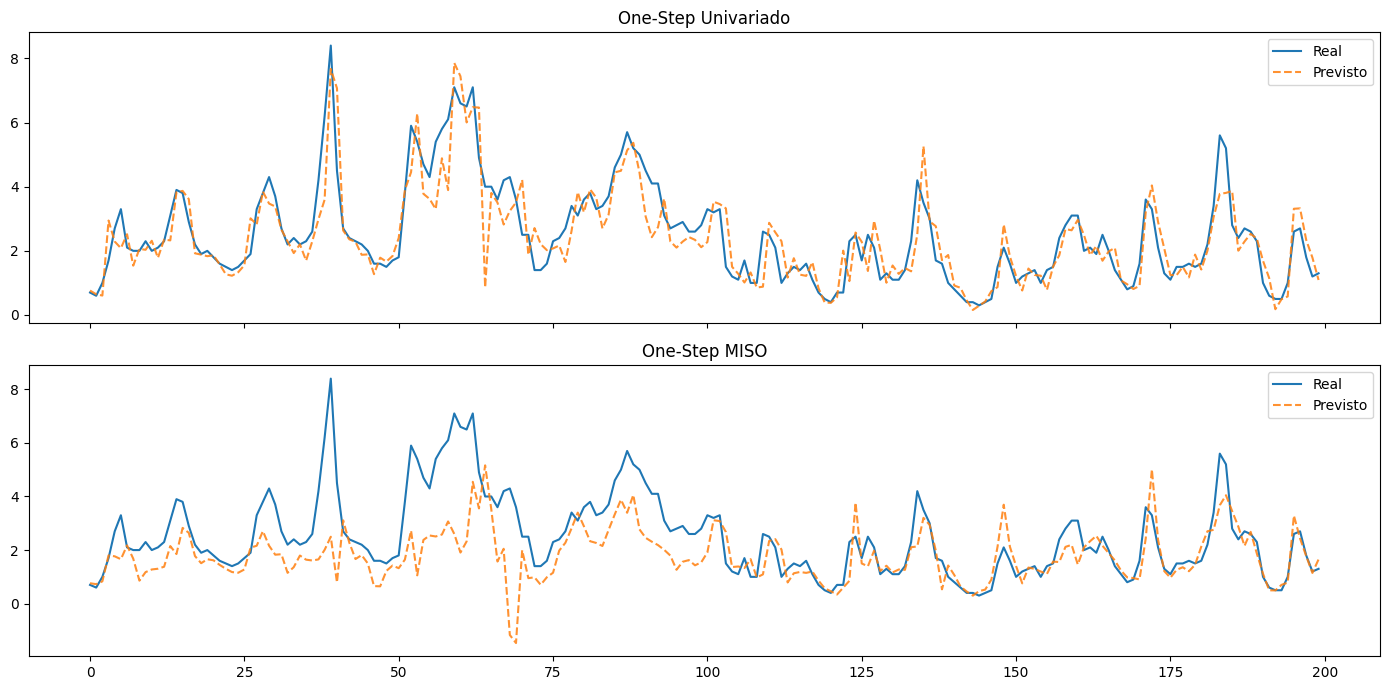

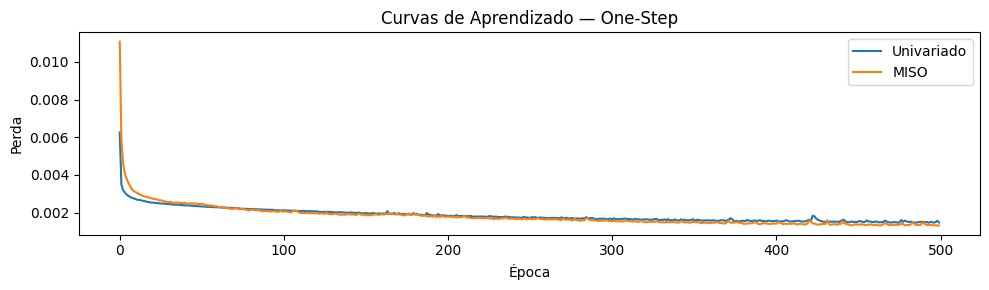

In [32]:
def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy().ravel()

yp_uni  = predict(model_uni,  X_uni_te)
yp_miso = predict(model_miso, X_miso_te)

evaluate(y_uni_te,  yp_uni,  label='Univariado', scaler=scaler, target_idx=target_idx)
evaluate(y_miso_te, yp_miso, label='MISO      ', scaler=scaler, target_idx=target_idx)

# Desnormaliza para visualização
def denorm(v):
    tmp = np.zeros((len(v), n_features)); tmp[:, target_idx] = v
    return scaler.inverse_transform(tmp)[:, target_idx]

N_plot = min(200, len(y_uni_te))
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, yt, yp, title in [
    (axes[0], y_uni_te[:N_plot],  yp_uni[:N_plot],  'One-Step Univariado'),
    (axes[1], y_miso_te[:N_plot], yp_miso[:N_plot], 'One-Step MISO'),
]:
    ax.plot(denorm(yt), label='Real',     linewidth=1.5)
    ax.plot(denorm(yp), label='Previsto', linestyle='--', alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 3))
plt.plot(hist_uni,  label='Univariado')
plt.plot(hist_miso, label='MISO')
plt.title('Curvas de Aprendizado — One-Step'); plt.xlabel('Época'); plt.ylabel('Perda')
plt.legend(); plt.tight_layout(); plt.show()

**Resposta Q4:**

**a) O modelo MISO apresenta desempenho melhor do que o univariado? A diferença é significativa?**
> *Escreva aqui.*

**b) As curvas de aprendizado diferem? O que isso sugere sobre a complexidade de cada problema?**
> *Escreva aqui.*

**c) Existem regiões onde o erro é maior? Os dois modelos falham nos mesmos pontos?**
> *Escreva aqui.*

**d) Quando lidamos com séries temporais, um dos grandes problemas que podemos encontrar á uma modelagem indesejada do tipo $\hat{y}(t+1) = y(t)$. Observe as métricas de avaliação obtidas, sobretudo o RRSE, e avalie o resultado obtido após o treinamento do modelo.**
> *Escreva aqui.*

---
### Q5 — Previsão Recursiva (Multi-Step): Univariado vs. MISO

Utilize as funções de previsão recursiva para gerar `HORIZON` passos à frente. Observe como o erro acumula em cada abordagem.

[Recursivo Univariado]  MSE=1.7185  RMSE=1.3109  MAE=0.9345  SSE=10.31  MAPE=0.41  RRSE*:2.26
[Recursivo MISO      ]  MSE=0.9852  RMSE=0.9926  MAE=0.5921  SSE=5.91  MAPE=0.25  RRSE*:1.71


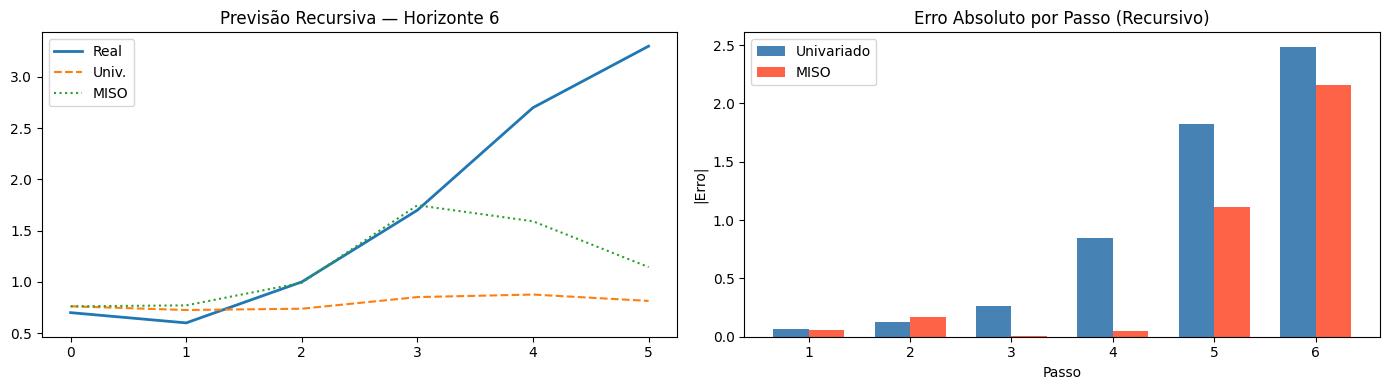

In [33]:
# --- Código fornecido: previsão recursiva ---
y_rec_uni  = recursive_forecast_univariate(
    model_uni, X_uni_te[0], horizon=HORIZON
)
y_rec_miso = recursive_forecast_multivariate(
    model_miso, X_miso_te[0], horizon=HORIZON,
    window_size=WINDOW_SIZE, n_features=n_features
)

y_true_h = y_uni_te[:HORIZON]

evaluate(y_true_h, y_rec_uni,  label='Recursivo Univariado', scaler=scaler, target_idx=target_idx)
evaluate(y_true_h, y_rec_miso, label='Recursivo MISO      ', scaler=scaler, target_idx=target_idx)

abs_uni  = np.abs(denorm(y_true_h) - denorm(y_rec_uni))
abs_miso = np.abs(denorm(y_true_h) - denorm(y_rec_miso))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(denorm(y_true_h), label='Real',      linewidth=2)
axes[0].plot(denorm(y_rec_uni),  label='Univ.',   linestyle='--')
axes[0].plot(denorm(y_rec_miso), label='MISO',    linestyle=':')
axes[0].set_title(f'Previsão Recursiva — Horizonte {HORIZON}')
axes[0].legend()

steps = np.arange(1, HORIZON + 1)
w = 0.35
axes[1].bar(steps - w/2, abs_uni,  w, label='Univariado', color='steelblue')
axes[1].bar(steps + w/2, abs_miso, w, label='MISO',       color='tomato')
axes[1].set_title('Erro Absoluto por Passo (Recursivo)')
axes[1].set_xlabel('Passo'); axes[1].set_ylabel('|Erro|')
axes[1].legend()
plt.tight_layout(); plt.show()

**Resposta Q5:**

**a) O erro aumenta ao longo do horizonte nos dois modelos? Este erro ocorre de forma semelhante?**
> *Escreva aqui.*

**b) Por que a abordagem recursiva tende a degradar com o horizonte? O MISO atenua esse problema?**
> *Escreva aqui.*

**c) A comparação one-step vs. recursivo é justa? Justifique.**
> *Escreva aqui.*

---
### Q6 — Previsão Direta: MISO vs. MIMO

Aqui introduzimos o modelo **MIMO** (*Multiple Input, Multiple Output*): uma única rede que prevê simultaneamente os próximos `HORIZON` valores de **todas** as features. Vamos comparar com a abordagem recursiva MISO.

In [34]:
# --- Código fornecido: modelo MISO direto (multi-output para o target) ---
X_miso_ms, y_miso_ms = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=HORIZON, mode='MISO'
)
X_miso_ms_tr, X_miso_ms_te = X_miso_ms[:split_mv], X_miso_ms[split_mv:]
y_miso_ms_tr, y_miso_ms_te = y_miso_ms[:split_mv], y_miso_ms[split_mv:]

loader_miso_ms = DataLoader(
    TimeSeriesDataset(X_miso_ms_tr, y_miso_ms_tr),
    batch_size=BATCH_SIZE, shuffle=False
)

# MISO direto: entrada multivariada, saída = HORIZON valores do target
model_miso_direct = MLP(
    n_input=WINDOW_SIZE * n_features,
    hidden_layers=[64, 32],
    n_output=HORIZON
)
print("=== MISO Direto (multi-step) ===")
train_model(model_miso_direct, loader_miso_ms, epochs=500, lr=1e-3, verbose=True)

=== MISO Direto (multi-step) ===
Época  100/500 | Perda: 0.005035
Época  200/500 | Perda: 0.004413
Época  300/500 | Perda: 0.004136
Época  400/500 | Perda: 0.003993
Época  500/500 | Perda: 0.003789


[0.014969340282804628,
 0.011403814461941476,
 0.010306630417564145,
 0.009424511200955344,
 0.008724612172435238,
 0.008272859670262459,
 0.008007917108660053,
 0.00786381729532935,
 0.007659420637840715,
 0.0075579624722844786,
 0.007456481067781588,
 0.00733145805688331,
 0.007248840494693944,
 0.00717246936660053,
 0.0071054218307605,
 0.007033631232930236,
 0.006974008561219163,
 0.006922091353483247,
 0.006876224038904415,
 0.0068350669705920615,
 0.006772039745844686,
 0.0067033672948748554,
 0.006665455378496849,
 0.006615023184355186,
 0.0065740912569232195,
 0.006536051912426335,
 0.00648818497575121,
 0.006453428705941723,
 0.006421237832996883,
 0.006383053820403773,
 0.006345428049075602,
 0.006309588613692627,
 0.006265883690156486,
 0.006235101060906706,
 0.006203386769306639,
 0.006187106133207664,
 0.0061302738250806075,
 0.006119829907667794,
 0.006065951023224948,
 0.0060649243591580585,
 0.006014524152435895,
 0.006013696343177885,
 0.005964499184864551,
 0.00593046

In [ ]:
# --- Código fornecido: modelo MIMO (prevê todas as features no horizonte) ---
loader_mimo_ms = DataLoader(
    TimeSeriesDataset(X_mimo_ms_tr, y_mimo_ms_tr),
    batch_size=BATCH_SIZE, shuffle=False
)

mimo_out_dim = HORIZON * n_features   # ex: 6 passos × 4 features = 24
model_mimo = MLP(
    n_input=WINDOW_SIZE * n_features,
    hidden_layers=[128, 64],
    n_output=mimo_out_dim
)
print("=== MIMO (multi-step, todas as features) ===")
train_model(model_mimo, loader_mimo_ms, epochs=500, lr=1e-3, verbose=True)

=== MIMO (multi-step, todas as features) ===
Época  100/500 | Perda: 0.005529
Época  200/500 | Perda: 0.004730


In [ ]:
# MISO direto
yp_miso_dir = predict(model_miso_direct, X_miso_ms_te[:1]).ravel()  # (HORIZON,)

# MIMO: extrai apenas a coluna do target
yp_mimo_flat = predict(model_mimo, X_mimo_ms_te[:1]).ravel()  # (HORIZON * n_features,)
yp_mimo_all  = yp_mimo_flat.reshape(HORIZON, n_features)      # (HORIZON, n_features)
yp_mimo_tgt  = yp_mimo_all[:, target_idx]                     # (HORIZON,) — target

y_true_h = y_miso_ms_te[0]  # (HORIZON,)

evaluate(y_true_h, y_rec_miso,    label='Recursivo MISO ', scaler=scaler, target_idx=target_idx)
evaluate(y_true_h, yp_miso_dir,   label='MISO Direto    ', scaler=scaler, target_idx=target_idx)
evaluate(y_true_h, yp_mimo_tgt,   label='MIMO (target)  ', scaler=scaler, target_idx=target_idx)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(denorm(y_true_h),    label='Real',            linewidth=2)
axes[0].plot(denorm(y_rec_miso),  label='Recursivo MISO',  linestyle='--')
axes[0].plot(denorm(yp_miso_dir), label='MISO Direto',     linestyle=':')
axes[0].plot(denorm(yp_mimo_tgt), label='MIMO (target)',   linestyle='-.')
axes[0].set_title(f'Comparação — Horizonte {HORIZON}')
axes[0].legend(); axes[0].set_xlabel('Passo')

# MIMO: todas as variáveis previstas (1 passo além do horizonte)
axes[1].set_title('MIMO — Previsão de Todas as Features (1º passo)')
first_step_pred = yp_mimo_all[0]   # (n_features,)
first_step_true = y_mimo_ms_te[0, :n_features]  # (n_features,)
x_pos = np.arange(n_features)
axes[1].bar(x_pos - 0.2, first_step_true, 0.4, label='Real')
axes[1].bar(x_pos + 0.2, first_step_pred, 0.4, label='Previsto')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(FEATURE_COLS, rotation=20, ha='right')
axes[1].legend()

plt.tight_layout(); plt.show()

**Resposta Q6:**

**a) Qual das três abordagens (recursiva, MISO direto, MIMO) apresentou previsões mais estáveis?**
> *Escreva aqui.*

**b) Qual é a vantagem conceitual do MIMO em relação ao MISO, além de prever o target?**
> *Escreva aqui.*

---
# Seção 3 — Avaliação de Ajustes de Parâmetros

Os experimentos desta seção usam o modelo **MISO** como padrão (one-step), por ser o mais direto para isolar o efeito de cada hiperparâmetro. Quando relevante, a comparação com o univariado é indicada.

---
### Q7 — Arquitetura da Rede

Compare múltiplas arquiteturas de MLP no modo MISO. Identifique sinais de overfitting e underfitting.

In [ ]:
architectures = {
    'Pequena  [16]':          [16],
    'Média    [64, 32]':      [64, 32],
    'Grande   [128, 64, 32]': [128, 64, 32],
    'Enorme   [256, 256]':    [256, 256],
}

results_arch = {}
for name, layers in architectures.items():
    m = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=layers, n_output=1)
    h = train_model(m, loader_miso, epochs=300, lr=1e-3, verbose=False)
    mse_tr = mean_squared_error(y_miso_tr, predict(m, X_miso_tr))
    mse_te = mean_squared_error(y_miso_te, predict(m, X_miso_te))
    results_arch[name] = {'train': mse_tr, 'test': mse_te, 'history': h}
    print(f"{name:<30}  MSE treino={mse_tr:.5f}  |  MSE teste={mse_te:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, res in results_arch.items():
    axes[0].plot(res['history'], label=name)
axes[0].set_title('Curva de Aprendizado por Arquitetura (MISO)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Perda'); axes[0].legend(fontsize=8)

names = list(results_arch.keys())
x = np.arange(len(names))
axes[1].bar(x - 0.2, [results_arch[n]['train'] for n in names], 0.4, label='Treino')
axes[1].bar(x + 0.2, [results_arch[n]['test']  for n in names], 0.4, label='Teste')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axes[1].set_title('MSE Treino vs. Teste — MISO'); axes[1].legend()
plt.tight_layout(); plt.show()

**Resposta Q7:**

**a) Identifique sinais de overfitting e underfitting nos resultados.**
> *Escreva aqui.*

**b) A arquitetura com melhor equilíbrio para o MISO é maior ou menor do que você esperaria para o univariado?**
> *Escreva aqui.*

---
### Q8 — Tamanho da Janela

Avalie o impacto do `WINDOW_SIZE` no MISO, considerando tanto o erro one-step quanto a estabilidade da previsão recursiva.

In [ ]:
# --- Código fornecido ---
window_sizes = [4, 8, 12, 24]
results_win  = {}

for ws in window_sizes:
    Xw, yw = make_windows_multivariate(
        df_scaled, TARGET_COL, FEATURE_COLS, ws, horizon=1, mode='MISO'
    )
    sp = n_train - ws
    Xw_tr, Xw_te = Xw[:sp], Xw[sp:]
    yw_tr, yw_te = yw[:sp], yw[sp:]

    ld = DataLoader(TimeSeriesDataset(Xw_tr, yw_tr), batch_size=BATCH_SIZE, shuffle=False)
    mw = MLP(n_input=ws * n_features, hidden_layers=[64, 32], n_output=1)
    train_model(mw, ld, epochs=300, lr=1e-3, verbose=False)

    mse_1 = mean_squared_error(yw_te, predict(mw, Xw_te))
    y_rec = recursive_forecast_multivariate(mw, Xw_te[0], HORIZON, ws, n_features)
    mse_r = mean_squared_error(yw_te[:HORIZON], y_rec)
    results_win[ws] = {'1step': mse_1, 'recursive': mse_r}
    print(f"ws={ws:3d}  MSE one-step={mse_1:.5f}  |  MSE recursivo={mse_r:.5f}")

fig, ax = plt.subplots(figsize=(9, 4))
ws_vals = list(results_win.keys())
ax.plot(ws_vals, [results_win[w]['1step']     for w in ws_vals], 'o-',  label='One-step (MISO)')
ax.plot(ws_vals, [results_win[w]['recursive'] for w in ws_vals], 's--', label='Recursivo (MISO)')
ax.set_title('Impacto do WINDOW_SIZE — MISO')
ax.set_xlabel('WINDOW_SIZE'); ax.set_ylabel('MSE (normalizado)')
ax.legend(); plt.tight_layout(); plt.show()

**Resposta Q8:**

**a) Como o WINDOW_SIZE afeta o erro one-step no MISO?**
> *Escreva aqui.*

**b) O efeito sobre o erro recursivo é diferente? Por quê pode ser diferente do caso univariado?**
> *Escreva aqui.*

---
### Q9 — Função de Perda

Compare os modelos MISO treinados com MSE, MAE e SSE. Avalie com as três métricas.

In [ ]:
# --- Código fornecido ---
class SSELoss(nn.Module):
    def forward(self, pred, target): return torch.sum((pred - target) ** 2)

loss_fns = {'MSELoss': nn.MSELoss(), 'MAELoss': nn.L1Loss(), 'SSELoss': SSELoss()}
results_loss = {}

for lname, lfn in loss_fns.items():
    m = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)
    train_model(m, loader_miso, epochs=300, lr=1e-3, loss_fn=lfn, verbose=False)
    mse, rmse, mae, sse = evaluate(
        y_miso_te, predict(m, X_miso_te),
        label=f'MISO + {lname}', scaler=scaler, target_idx=target_idx
    )
    results_loss[lname] = {'mse': mse, 'rmse': rmse, 'mae': mae, 'sse': sse}

**Resposta Q9:**

**a) Qual função de perda apresentou melhor desempenho nas métricas? Este achado faz sentido?**
> *Escreva aqui.*

**b) Em quais situações cada função parece mais adequada para séries temporais?**
> *Escreva aqui.*

---
### Q10 — Sensibilidade a Hiperparâmetros

Avalie o impacto de pequenas mudanças nos hiperparâmetros do modelo MISO.

In [ ]:
grid = [
    {'neurons': 16,  'epochs': 200, 'lr': 1e-3},
    {'neurons': 64,  'epochs': 200, 'lr': 1e-3},
    {'neurons': 64,  'epochs': 500, 'lr': 1e-3},
    {'neurons': 64,  'epochs': 200, 'lr': 1e-2},
    {'neurons': 128, 'epochs': 200, 'lr': 1e-3},
    {'neurons': 128, 'epochs': 500, 'lr': 1e-4},
]

hp_results = []
for cfg in grid:
    m = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[cfg['neurons']], n_output=1)
    train_model(m, loader_miso, epochs=cfg['epochs'], lr=cfg['lr'], verbose=False)
    mse_te = mean_squared_error(y_miso_te, predict(m, X_miso_te))
    hp_results.append({**cfg, 'test_mse': mse_te})
    print(f"neurons={cfg['neurons']:3d}  epochs={cfg['epochs']:4d}  lr={cfg['lr']}  →  MSE={mse_te:.5f}")

print("\n", pd.DataFrame(hp_results).sort_values('test_mse').to_string(index=False))

**Resposta Q10:**

**a) Quais hiperparâmetros causaram maiores mudanças no desempenho do modelo MISO? A sensibilidade é diferente do que você observaria num modelo univariado?**
> *Escreva aqui.*

---
# Seção 4 — Avaliação Aprofundada de Séries Temporais

---
### Q11 — Por que não usar shuffle?

O código abaixo treina dois modelos MISO idênticos, sendo um com `shuffle=True`, outro com `shuffle=False`. O objetivo é comparar o desempenho.

In [ ]:
ds_miso = TimeSeriesDataset(X_miso_tr, y_miso_tr)
ld_shuf = DataLoader(ds_miso, batch_size=BATCH_SIZE, shuffle=True)
ld_nosh = DataLoader(ds_miso, batch_size=BATCH_SIZE, shuffle=False)

m_shuf = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)
m_nosh = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)
m_nosh.load_state_dict(m_shuf.state_dict())   # mesmos pesos iniciais

print("shuffle=True")
h_shuf = train_model(m_shuf, ld_shuf, epochs=300, lr=1e-3, verbose=False)
print("shuffle=False")
h_nosh = train_model(m_nosh, ld_nosh, epochs=300, lr=1e-3, verbose=False)

evaluate(y_miso_te, predict(m_shuf, X_miso_te), label='MISO shuffle=True ', scaler=scaler, target_idx=target_idx)
evaluate(y_miso_te, predict(m_nosh, X_miso_te), label='MISO shuffle=False', scaler=scaler, target_idx=target_idx)

plt.figure(figsize=(10, 3))
plt.plot(h_shuf, label='shuffle=True')
plt.plot(h_nosh, label='shuffle=False')
plt.title('Curva de Aprendizado — Efeito do Shuffle (MISO)')
plt.xlabel('Época'); plt.ylabel('Perda'); plt.legend()
plt.tight_layout(); plt.show()

**Resposta Q11:**

**Por que embaralhar os dados é problemático para séries temporais, mesmo no modo MISO? O experimento acima confirma ou contraria essa intuição?**
> *Escreva aqui.*

---
### Q12 — Diferenciação da Série

O código aplica diferenciação de 1ª ordem **apenas à variável target** antes de construir as janelas MISO. Compare com o modelo treinado na série original.

In [ ]:
# --- Código fornecido ---
df_diff = df_scaled.copy()
df_diff[TARGET_COL] = df_diff[TARGET_COL].diff().fillna(0)

Xd, yd = make_windows_multivariate(
    df_diff, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MISO'
)
Xd_tr, Xd_te = Xd[:split_mv], Xd[split_mv:]
yd_tr, yd_te = yd[:split_mv], yd[split_mv:]

ld_diff = DataLoader(TimeSeriesDataset(Xd_tr, yd_tr), batch_size=BATCH_SIZE, shuffle=False)
m_diff  = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)

print("=== MISO + série diferenciada ===")
hist_diff = train_model(m_diff, ld_diff, epochs=500, lr=1e-3, verbose=True)

mse_orig = mean_squared_error(y_miso_te, predict(model_miso, X_miso_te))
mse_diff = mean_squared_error(yd_te,     predict(m_diff,     Xd_te))
print(f"\nMSE MISO original     : {mse_orig:.5f}")
print(f"MSE MISO diferenciado : {mse_diff:.5f}")

plt.figure(figsize=(10, 3))
plt.plot(hist_miso[:500], label='MISO original')
plt.plot(hist_diff,       label='MISO diferenciado')
plt.title('Curvas de Aprendizado — Efeito da Diferenciação')
plt.xlabel('Época'); plt.ylabel('Perda'); plt.legend()
plt.tight_layout(); plt.show()

**Resposta Q12:**

**a) Qual modelo generaliza melhor: MISO na série original ou na diferenciada?**
> *Escreva aqui.*

**b) A diferenciação afeta igualmente todos os modelos (univariado, MISO, MIMO)?**
> *Escreva aqui.*

---
### Q13 — Média Móvel como Pré-processamento

A média móvel é aplicada **apenas ao target** antes de construir as janelas. As features exógenas permanecem sem suavização. Compare com o MISO original.

In [ ]:
# --- Código fornecido ---
MA_WIN = 5
df_ma  = df_scaled.copy()
df_ma[TARGET_COL] = df_ma[TARGET_COL].rolling(MA_WIN, min_periods=1).mean()

Xma, yma = make_windows_multivariate(
    df_ma, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MISO'
)
Xma_tr, Xma_te = Xma[:split_mv], Xma[split_mv:]
yma_tr, yma_te = yma[:split_mv], yma[split_mv:]

ld_ma = DataLoader(TimeSeriesDataset(Xma_tr, yma_tr), batch_size=BATCH_SIZE, shuffle=False)
m_ma  = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)

print("=== MISO + média móvel ===")
train_model(m_ma, ld_ma, epochs=500, lr=1e-3, verbose=True)

mse_ma   = mean_squared_error(yma_te,    predict(m_ma,     Xma_te))
mse_base = mean_squared_error(y_miso_te, predict(model_miso, X_miso_te))

print(f"\nMSE MISO sem pré-proc. : {mse_base:.5f}")
print(f"MSE MISO + média móvel : {mse_ma:.5f}")

N_plot = min(150, len(yma_te))
plt.figure(figsize=(14, 4))
plt.plot(denorm(yma_te[:N_plot]),               label='Real (MA)',       linewidth=2)
plt.plot(denorm(predict(m_ma, Xma_te)[:N_plot]),label='Prev. MISO+MA',  linestyle='--')
plt.plot(denorm(predict(model_miso, X_miso_te)[:N_plot]),
         label='Prev. MISO original', linestyle=':')
plt.title('Comparação — MISO com e sem Média Móvel')
plt.legend(); plt.tight_layout(); plt.show()

**Resposta Q13:**

**a) O pré-processamento por média móvel surtiu efeito positivo no MISO?**
> *Escreva aqui.*

**b) Faz sentido suavizar apenas o target e manter as exógenas brutas? Quais são os prós e contras?**
> *Escreva aqui.*

---
### Q14 — Análise Temporal do Erro

Analise os resíduos ao longo do tempo para o modelo MISO. Verifique se o erro é constante ou apresenta padrões sistemáticos.

In [ ]:
# --- Código fornecido ---
yp_miso_full = predict(model_miso, X_miso_te)

yt_orig = denorm(y_miso_te)
yp_orig = denorm(yp_miso_full)
residuals  = yt_orig - yp_orig
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(residuals, color='darkorange', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Resíduos ao Longo do Tempo — MISO', fontsize=12)
axes[0].set_ylabel('Erro (real − previsto)')

roll_e = pd.Series(abs_errors).rolling(10).mean()
axes[1].plot(abs_errors, alpha=0.3, label='|Erro|')
axes[1].plot(roll_e,     color='red', label='Média móvel (w=10)')
axes[1].set_title('Erro Absoluto e Média Móvel', fontsize=12)
axes[1].legend()

axes[2].scatter(yt_orig, residuals, alpha=0.3, s=10)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Resíduo vs. Valor Real', fontsize=12)
axes[2].set_xlabel('Valor real'); axes[2].set_ylabel('Resíduo')

plt.tight_layout(); plt.show()

print(f"Média dos resíduos : {residuals.mean():.4f}")
print(f"Desvio dos resíduos: {residuals.std():.4f}")
print(f"Maior erro absoluto: {abs_errors.max():.4f} (índice {abs_errors.argmax()})")

**Resposta Q14:**

**a) O erro do MISO é constante ao longo do tempo?**
> *Escreva aqui.*

**b) Existem regiões de falha sistemática? Compare com o que você observaria no modelo univariado.**
> *Escreva aqui.*

**c) O gráfico de resíduo vs. valor real revela algum padrão (heteroscedasticidade, viés)?**
> *Escreva aqui.*

---
### Q15 — Limitações do MLP para Séries Temporais

Com base em todos os experimentos realizados, reflita sobre as limitações do MLP, tanto na versão univariada quanto nas versões MISO e MIMO.

**Resposta Q15:**

**a) Quais são as principais limitações do MLP no contexto de séries temporais univariadas?**
> *Escreva aqui.*

**b) O uso de features exógenas (MISO) resolve alguma dessas limitações? Quais permanecem?**
> *Escreva aqui.*

**c) A abordagem MIMO apresenta limitações específicas que o MISO não tem?**
> *Escreva aqui.*

**d) Em quais situações o MLP (nas três variantes) não é adequado? Que arquiteturas seriam mais apropriadas?**
> *Escreva aqui.*